<a href="https://colab.research.google.com/github/Skywalk-dev/tensorflow-developer-certificate/blob/main/01_tensorflow_fundamentals/01_neural_network_regression_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introduction to Regression with neural network in tensorflow.

predicting a numerical variable based on some other combination of variables, even shorter predicting number.

In [ ]:
#Import tensorflow
import tensorflow as tf

tf.__version__


'2.20.0'

## Creating a data to view and fit

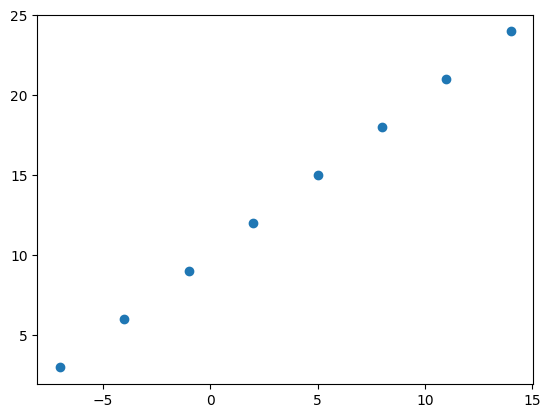

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
## Create a feature
X = np.array([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0])

## Create lables
y = np.array([3.0,6.0,9.0,12.0,15.0,18.0,21.0,24.0])

## visualize it
plt.scatter(X,y)

In [ ]:
y == X+10

array([ True,  True,  True,  True,  True,  True,  True,  True])

## Input and output shapes



In [ ]:
## Lets create a demo tensor for our housing price prediction problem.

house_info = tf.constant(["bedroom","bathroom","garrage"])
house_price = tf.constant([939700])
house_info,house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garrage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [ ]:
input_shape = X.shape
output_shape = y.shape
input_shape, output_shape

((8,), (8,))

In [ ]:
# turn numpy arrays into tensors

X = tf.constant(X)
y = tf.constant(y)
X,y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

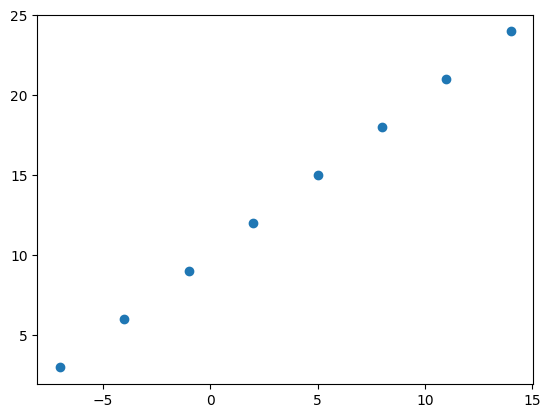

In [ ]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape , output_shape
plt.scatter(X,y)

## Steps in modeling with Tensorflow
1. **Creating a model** - define the input and output layers, as well as the hiden layers of a deep learning model.(part of nural network )
2. **Compiling a model** - define the loss function( in other words, the function which tells our model how wrong it is ) and the optimizer(is it tells the model how to improve the pattern its learning ) and evaluation matrix(what we can use to interpret the performance of our model ).
3. **Fitting a model** - lettting the model to find patterns beween x and y (features and lables ).


In [ ]:
## set some random seed
tf.random.set_seed(42)

## 1. Create a number using the Sequencial API

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])


## 2. Compile the model
model.compile(loss = tf.keras.losses.mae, # mae stands for mean absolute error
              optimizer= tf.keras.optimizers.SGD(), # sgd is shortform of stochastic gradient descent
              metrics = ['mae'])

##3 Fit the model
model.fit(X,y , epochs= 5)




Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 19.3164 - mae: 19.3164
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 19.0351 - mae: 19.0351
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 18.7539 - mae: 18.7539
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 18.4726 - mae: 18.4726
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 18.1914 - mae: 18.1914


In [ ]:
# Checkout Xand y
X,y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [ ]:
# Try and make out a prediction using our model
import tensorflow as tf

model.predict(tf.constant([17.0]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


array([[-16.7625]], dtype=float32)

# Improving our model
 We can improve the model by altering the steps we took to created the model.

 1. **Creating a model** - here we may add more layers, increase the number of hidden units(all called neurons)
 within each of the hidden layers, change the activation function of each layer.
 2. **Compailing a model** - here we might change the optimization function
  or perhaps the **learning rate** of the optimization function.
 3. **Fitting a model** - here we fit a model for more
  **epochs**(leave it training for longer) or on more data (give the model more examples to learn from ).

In [ ]:
# Lets rebuild our model

#1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (1,)),
    tf.keras.layers.Dense(1)
])
#2. Compile the model
model.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ['mae'])
#3 Fit the model (this time we will train for longer)
model.fit(X,y ,epochs = 100)



Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 11.2812 - mae: 11.2812
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 11.2767 - mae: 11.2767
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 11.2722 - mae: 11.2722
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 11.2677 - mae: 11.2677
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 11.2632 - mae: 11.2632
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - loss: 11.2587 - mae: 11.2587
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 11.2542 - mae: 11.2542
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - loss: 11.2497 - mae: 11.2497
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 11.2452 - mae: 11.2452
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - loss: 11.2407 - mae: 11.2407
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 11.2362 - mae: 11.2362
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 11.2317 - mae: 11.2317
Epoch 13/100
1/1

In [ ]:
# Remind ourself of the data
X,y

(<tf.Tensor: shape=(8,), dtype=float64, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.])>,
 <tf.Tensor: shape=(8,), dtype=float64, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.])>)

In [ ]:
# We will se if our model prediction has improved

model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[12.57683]], dtype=float32)

In [ ]:
# lets see if we can make another to improve our model

# 1. Create the model(this time add extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape =(1,)),
    tf.keras.layers.Dense(100,activation = "relu"),
    tf.keras.layers.Dense(1),
])
#2. Compile the model
model.compile(
    loss= "mae",
    optimizer = tf.keras.optimizers.Adam(),
    metrics = ["mae"]
)
# 3 Fit tyhe model
model.fit(X,y , epochs= 100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 892ms/step - loss: 12.1858 - mae: 12.1858
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.0916 - mae: 12.0916
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 11.9964 - mae: 11.9964
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.9019 - mae: 11.9019
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.8075 - mae: 11.8075
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 11.7131 - mae: 11.7131
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.6187 - mae: 11.6187
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 11.5247 - mae: 11.5247
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11.4311 - mae: 11.4311
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 11.3379 - mae: 11.3379
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.2447 - mae: 11.2447
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11.1516 - mae: 11.1516
Epoch 13/100
1/1 ━━━━━━━

In [ ]:
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[31.19401]], dtype=float32)

In [ ]:
# 1. create a model

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (1,)),
    tf.keras.layers.Dense(50,activation = None),
    tf.keras.layers.Dense(1)
])
# 2. Compile the model
model.compile(
    loss = "mae",
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics = ["mae"]
)
#3 Fit the model
model.fit(X,y,epochs = 50)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step - loss: 12.6614 - mae: 12.6614
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.9171 - mae: 11.9171
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.1710 - mae: 11.1710
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 10.4203 - mae: 10.4203
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 9.6627 - mae: 9.6627
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 8.8958 - mae: 8.8958
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 8.1178 - mae: 8.1178
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 7.3269 - mae: 7.3269
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 6.8017 - mae: 6.8017
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 6.9561 - mae: 6.9561
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.2333 - mae: 7.2333
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4251 - mae: 7.4251
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - 

In [ ]:
# Lets try to make a prediction
model.predict(tf.constant([17.0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


array([[27.636261]], dtype=float32)

## Common ways to improver a dep model:
1. Adding layers
2. Increase the number of hidden units
3. Change the activation function
4. Change the optimization function
5. Change the learning rate.
6. Fitting on more data
7. Fitting for longer



Evaluating a model.
 In practice, a typical workflow you'll go through when buiding neural network is
```
 Build a model -> fit it-> evaluate it -> tweak a model -> fit it -> evaluate it ->tweak a model-> fit it-> evaluate it -> ....
 ```

When it comes to evaluation... there are 3 words i should memorise:
> "Visualize, Visualize,Visualize"

its a good idea to visualize
* The data - what data are we working with? What does it look like?
* The model itself - what does our model look like?
* The training of a model - how does a model perform while it learns?
* The predictions of the model - how the predictions of the model line up against the ground truth (the original labels)?



In [ ]:
#Make a bigger data set
X= tf.range(-100,100,4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [ ]:
# Make lables for the data set
y = X+10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

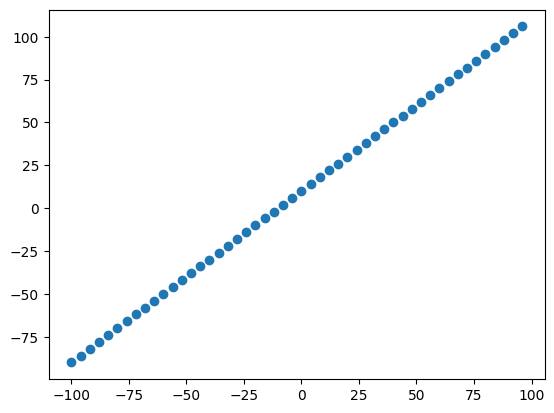

In [ ]:
# Visualize the data
import matplotlib.pyplot as plt
plt.scatter(X,y)

### the 3 sets...

* **Training set** - The model learns from the data, which is which is 70% - 80% percent of the total data we have available.
* **Validation set** - The model gets tuned on thsi data, which is typically 10 to 15%  of the data available.
* **Test set** - The model gets evaluated on this data to test what it has learned, this is typically 10 to 15 % of the data available.

In [ ]:
# CHeck the length of data we have
len(X)

50

In [ ]:
# Split the data into training and test set
X_train = X[:40] # first 40 are training samples(80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples(20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)


(40, 10, 40, 10)

### Visualizing the data
 Now we've got our data in training and testing sets... let's visualize it again

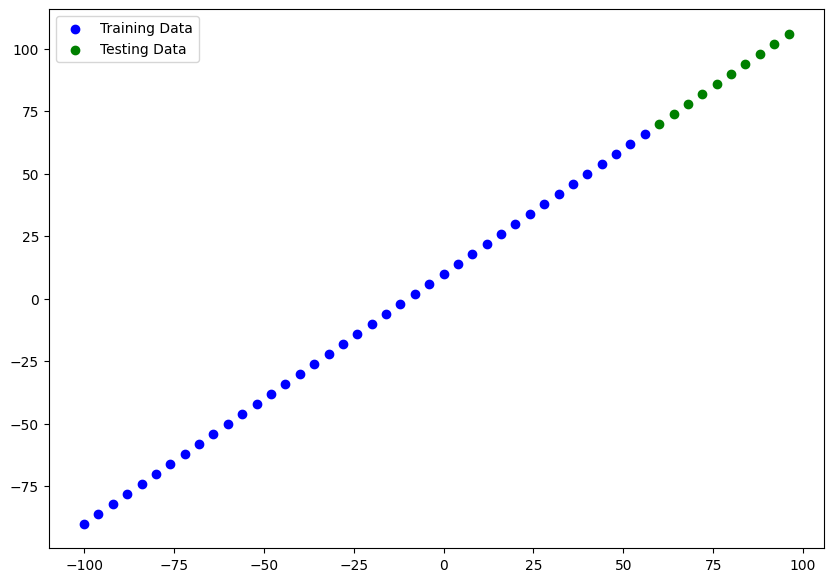

In [ ]:
plt.figure(figsize =(10,7)),
# Plot training data in blue
plt.scatter(X_train,y_train,c= 'b', label = "Training Data")
#Plot testing data in green
plt.scatter(X_test, y_test, c='g', label = "Testing Data")
# show a legend
plt.legend();

In [ ]:
## Lets see how to build a nural network for our data
# Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (1,)),
    tf.keras.layers.Dense(1)
])
#Compile the model
model.compile(
              loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ["mae"])
#Fit in the model
#model.fit(X_train,y_train,epochs = 50)



In [ ]:
# Lets create a model which builds automatically by defining the input shape argument
tf.random.set_seed(42)

# Create a model same as previous
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape = (1,)),
    tf.keras.layers.Dense(1,name="Input_layer"),
    tf.keras.layers.Dense(1, name= "Output_layer")
], name= "model_1")
#Compile the model
model.compile(
              loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(),
              metrics = ["mae"])
model.summary()




Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (Dense)             │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

* Total params - total number of parameters in the model.
* Trainable parameters - these are the paremeters(patterns) the model can update as it trains.
* Non - trainable params - These parameters arent updated during training(this is typical when you bring in already learnt parameter or parameters from other models during **transfer learning**).


In [ ]:
#Lets fit the model in the training data
model.fit(X_train, y_train, epochs = 100 , verbose = 0)

In [ ]:
#Get a summary of our model
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_layer (Dense)             │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

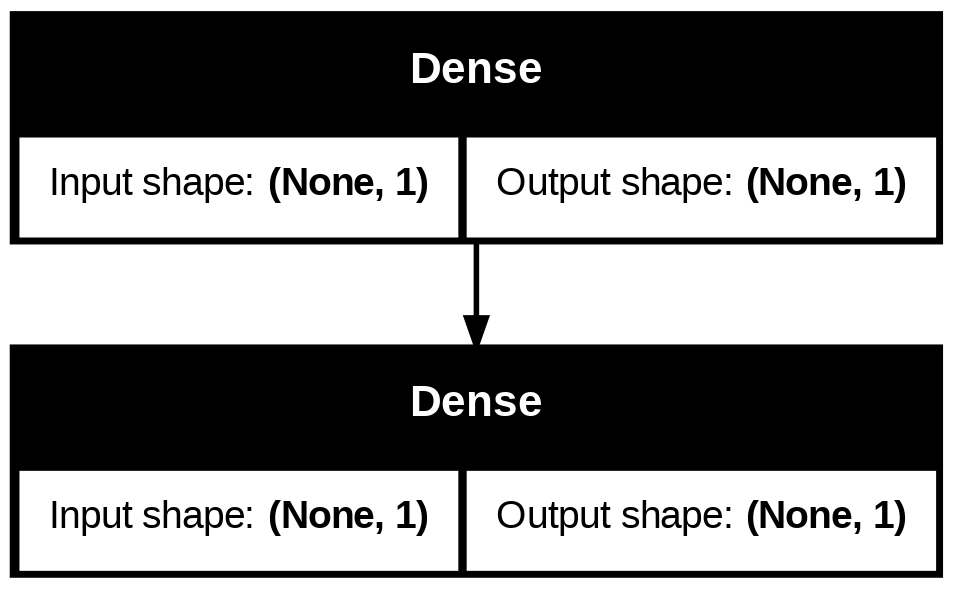

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(model = model, show_shapes=True)

## Visualizing our models predictions

To visualize predictions, it is a good idea to plot them against the ground truth labels.

often you will see this in the form of `y_test` or `y_true` versus `y_pred`(ground truth versus your model's predictions)


In [ ]:
# Make some predictions
y_pred = model.predict(X_test)
y_pred



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


array([[ 6.297604 ],
       [ 6.731732 ],
       [ 7.1658597],
       [ 7.599988 ],
       [ 8.034116 ],
       [ 8.468244 ],
       [ 8.902372 ],
       [ 9.3365   ],
       [ 9.770628 ],
       [10.204756 ]], dtype=float32)

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
# Lets create a ploting functin
# Lets create a plotting function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_pred):
    """
    Plot training data, test data and compare predictions to ground truth labels.
    """

    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels,
                c="b", label="Training data")

    # Plot test data in green
    plt.scatter(test_data, test_labels,
                c="g", label="Testing data")

    # Plot model predictions in red
    plt.scatter(test_data, predictions,
                c="r", label="Predictions")

    plt.legend()

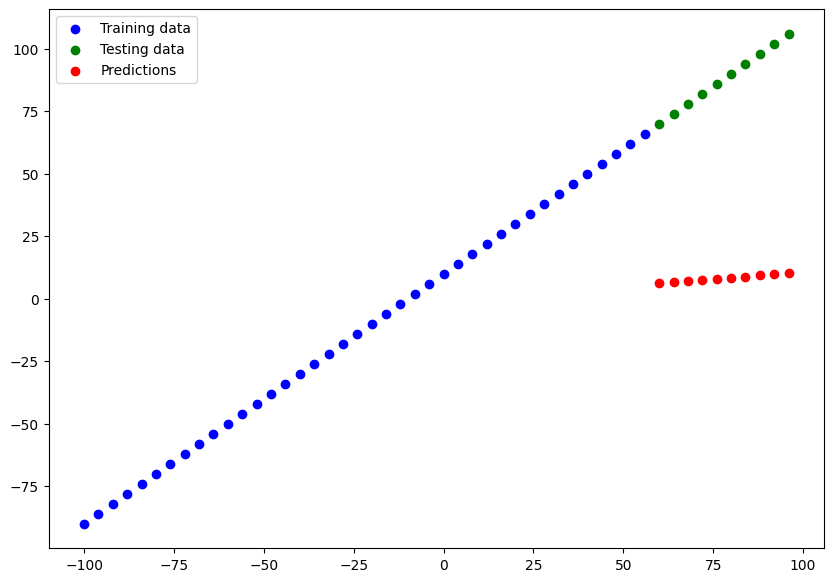

In [ ]:
plot_predictions()

Evaluating our moodels prediction with regression evaluation metrics
Depending on the problem you are working on, there will be different evaluation metrics to evaluate your model's performance.

Since we are working on regression,two of the main metrics:


*   MAE - mean absolute error- "on average ho wrong is each of my model's prediction"
*   MSE - mean square error - square the average error.




In [ ]:
# Evaluate the model on the test
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 79.7488 - mae: 79.7488


[79.74881744384766, 79.74881744384766]

In [ ]:
# Calculate the mean absolute error

mae = tf.metrics.mae(y_true=y_test,
                     y_pred = tf.constant(y_pred))
mae


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([63.702396, 67.268265, 70.83414 , 74.40001 , 77.96588 , 81.53175 ,
       85.097626, 88.6635  , 92.22937 , 95.79524 ], dtype=float32)>

In [ ]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[ 6.297604 ],
       [ 6.731732 ],
       [ 7.1658597],
       [ 7.599988 ],
       [ 8.034116 ],
       [ 8.468244 ],
       [ 8.902372 ],
       [ 9.3365   ],
       [ 9.770628 ],
       [10.204756 ]], dtype=float32)>

In [ ]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

In [ ]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([ 6.297604 ,  6.731732 ,  7.1658597,  7.599988 ,  8.034116 ,
        8.468244 ,  8.902372 ,  9.3365   ,  9.770628 , 10.204756 ],
      dtype=float32)>

In [ ]:
# calculate the mean absolute error.

mae = tf.metrics.mae(y_true=y_test, y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=79.74881744384766>

In [ ]:
# MAke some functions to reuse mae and MSE

def mae(y_true , y_pred):
   return tf.metrics.mae(y_true = y_true, y_pred = tf.squeeze(y_pred))

def mse(y_true,y_pred):
  return tf.metrics.mse(y_true = y_true, y_pred = tf.squeeze(y_pred))

## Running experiments to improve our models

```
Build a model -> fit it -> evaluate it -> tweak it -> fit it-> evaluate it-> tweak it -> fit it-> evaluate it...
```

1. Get more data - get more examples for your model to train on (more opportunities to learn patterns or relationsships between features and labels)

2. Make your model larger - (using more complex model) - this might come on more layers or more more hidden units in each layer.

3. Train for longer - give your model more of a chance to find patterns in the data.

Let's do 3 modeling experiments.

1. `model_1` - same as the original model , 1 layer, traned for 100 epochs.
2. `model_2 - 2 layers, trained for 100 epochs.
3. `model_3 - 2 layers, trained for 500 epochs.



In [ ]:
X_train = tf.reshape(X_train,(-1,1))
X_test = tf.reshape(X_test,(-1,1))

print(X_train.shape, X_test.shape)

(40, 1) (10, 1)


In [ ]:
## Build model_1

# set random seed
tf.random.set_seed(42)

# 1 Create the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)
])

# 2 Compile the model
model_1.compile(loss = tf.keras.losses.mae,
                optimizer = tf.keras.optimizers.SGD(),
                metrics = ['mae'])
# 3 Fit the model

model_1.fit(X_train,y_train , epochs=100)



Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 23.1649 - mae: 23.1649 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 11.3723 - mae: 11.3723
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 8.9119 - mae: 8.9119 
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 10.0213 - mae: 10.0213 
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 11.5019 - mae: 11.5019
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.9878 - mae: 8.9878
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 10.0971 - mae: 10.0971
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.6394 - mae: 11.6394
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 12.6230 - mae: 12.6230
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 8.3846 - mae: 8.3846
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 9.0758 - mae: 9.0758
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 8.0705 - mae: 8.0705
Epoch 13/100
2/2 ━━━━━━━━━━━━━━━

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (40, 1)
y_train shape: (40,)


In [ ]:
model_1.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (20.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


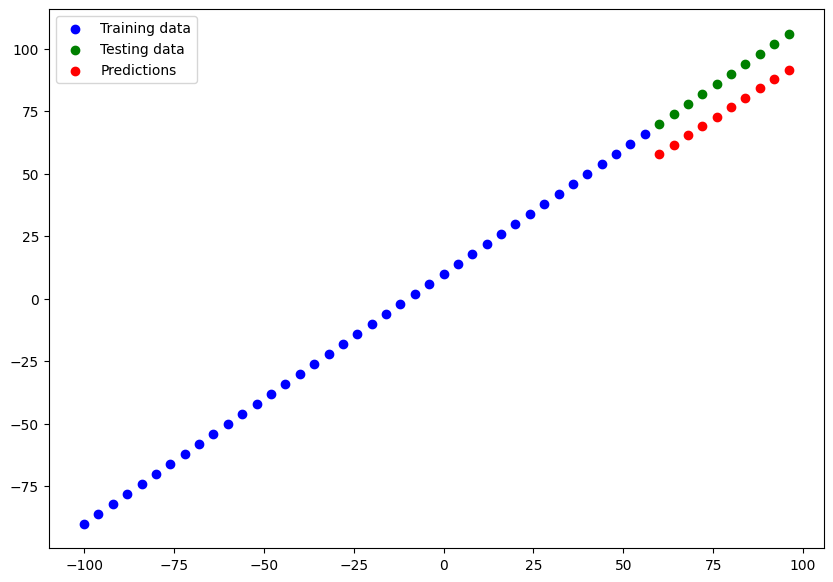

In [ ]:
# Make a plot predictions fro model_1

y_pred_1 = model_1.predict(X_test)
plot_predictions(predictions=y_pred_1)



In [ ]:
# Calculate model_1 evaluation metrics
mae_1 = mae(y_test, y_pred_1)
mse_1 = mse(y_test, y_pred_1)
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=13.263442993164062>,
 <tf.Tensor: shape=(), dtype=float32, numpy=176.39369201660156>)

** Build `model_2`**

* 2 dense layers, trained for 100 epochs

In [ ]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model

model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss = tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.SGD(),
              metrics = ['mse'])

# 3. Fit the model

model_2.fit(X_train, y_train, epochs = 100)


Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 23.4131 - mse: 888.6785 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 21.4049 - mse: 650.8846
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 21.0279 - mse: 602.1393
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 14.1895 - mse: 326.6393
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 18.4134 - mse: 454.7132
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 13.6990 - mse: 282.7432
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.3574 - mse: 328.8352
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 15.9591 - mse: 343.4129
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 12.5232 - mse: 241.3127
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.1292 - mse: 315.6122
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 11.6414 - mse: 216.6748
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.0350 - mse: 311.8444
Epoch 13/100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


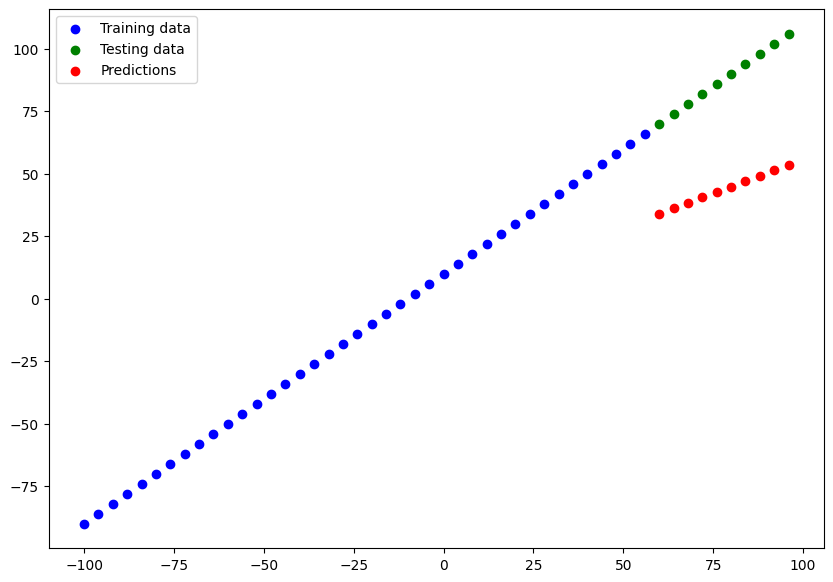

In [ ]:
# Make and plot predictions of model_2

y_pred_2 = model_2.predict(X_test)
plot_predictions(predictions = y_pred_2)

In [ ]:
model_2.evaluate(X_test, y_test)
print(X_train[:10])
print(y_train[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 44.1775 - mse: 1979.3756
tf.Tensor(
[[-100]
 [ -96]
 [ -92]
 [ -88]
 [ -84]
 [ -80]
 [ -76]
 [ -72]
 [ -68]
 [ -64]], shape=(10, 1), dtype=int32)
tf.Tensor([-90 -86 -82 -78 -74 -70 -66 -62 -58 -54], shape=(10,), dtype=int32)


In [ ]:
model_2.summary()
y_pred_2 = model_2.predict(X_test)
print(y_pred_2[:10])

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[34.071392]
 [36.2383  ]
 [38.40521 ]
 [40.572117]
 [42.739025]
 [44.90593 ]
 [47.072834]
 [49.239742]
 [51.40665 ]
 [53.57356 ]]
